*Importando Libs*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

*Análise Exploratória*

In [4]:
df = pd.read_csv('../data/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   hours_studied                     10000 non-null  int64  
 1   previous_scores                   10000 non-null  int64  
 2   extracurricular_activities        10000 non-null  object 
 3   sleep_hours                       10000 non-null  int64  
 4   sample_question_papers_practiced  10000 non-null  int64  
 5   performance_index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

In [11]:
df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
hours_studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
previous_scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
sleep_hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
sample_question_papers_practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
performance_index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


*Matriz de Correlação*

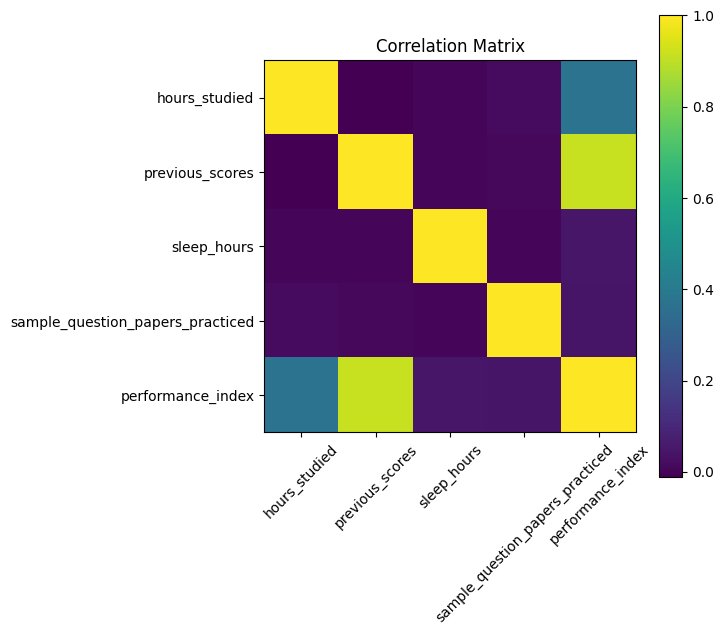

In [13]:
corr = df[colunas_numericas].corr()
plt.figure(figsize=(6, 6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(colunas_numericas)), colunas_numericas, rotation=45)
plt.yticks(range(len(colunas_numericas)), colunas_numericas)

plt.title('Correlation Matrix')
plt.show()

array([[<Axes: xlabel='hours_studied', ylabel='hours_studied'>,
        <Axes: xlabel='previous_scores', ylabel='hours_studied'>,
        <Axes: xlabel='sleep_hours', ylabel='hours_studied'>,
        <Axes: xlabel='sample_question_papers_practiced', ylabel='hours_studied'>,
        <Axes: xlabel='performance_index', ylabel='hours_studied'>],
       [<Axes: xlabel='hours_studied', ylabel='previous_scores'>,
        <Axes: xlabel='previous_scores', ylabel='previous_scores'>,
        <Axes: xlabel='sleep_hours', ylabel='previous_scores'>,
        <Axes: xlabel='sample_question_papers_practiced', ylabel='previous_scores'>,
        <Axes: xlabel='performance_index', ylabel='previous_scores'>],
       [<Axes: xlabel='hours_studied', ylabel='sleep_hours'>,
        <Axes: xlabel='previous_scores', ylabel='sleep_hours'>,
        <Axes: xlabel='sleep_hours', ylabel='sleep_hours'>,
        <Axes: xlabel='sample_question_papers_practiced', ylabel='sleep_hours'>,
        <Axes: xlabel='performance_

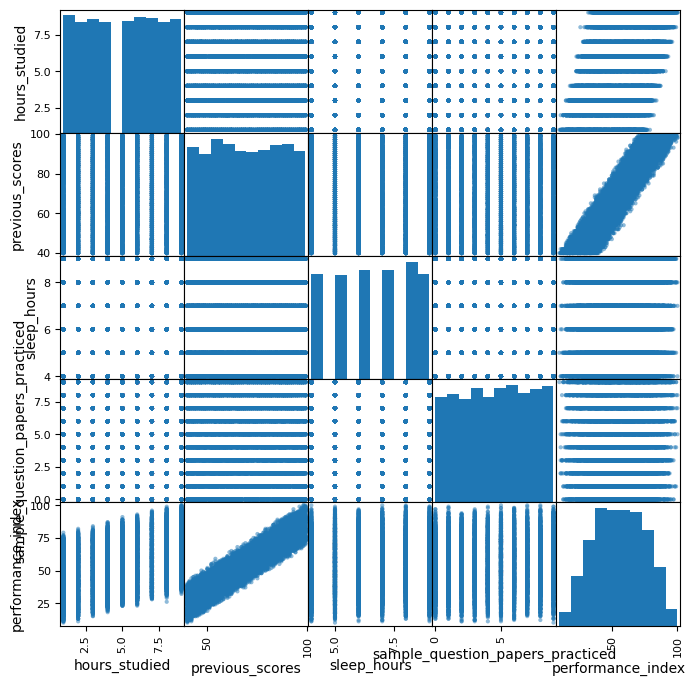

In [16]:
pd.plotting.scatter_matrix(df[colunas_numericas], figsize=(8,8))

A partir da matriz de correlação, observamos que previous_scores apresenta forte correlação com a variável alvo, enquanto sleep_hours e sample_question_papers_practiced possuem baixa correlação.

**Preparação dos Dados**

*Identificação de Outliers*

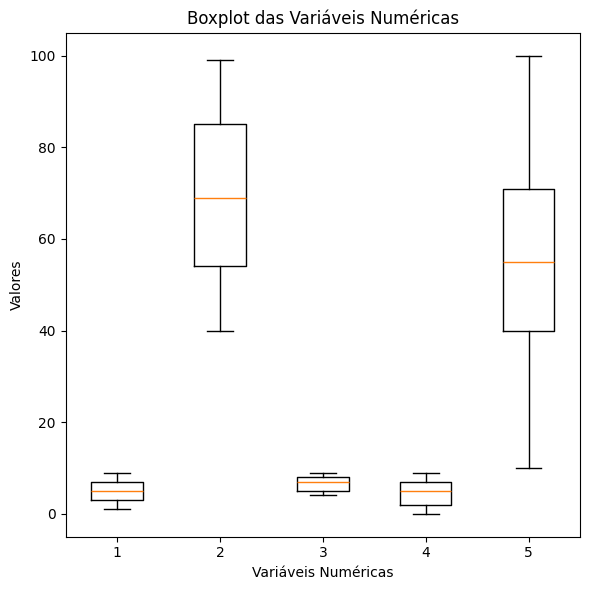

In [19]:
plt.figure(figsize=(6, 6))
plt.boxplot(df[colunas_numericas])
plt.xlabel('Variáveis Numéricas')
plt.ylabel('Valores')
plt.title('Boxplot das Variáveis Numéricas')
plt.tight_layout()
plt.show()

In [21]:
def detecta_outliers(serie, fator=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)   
    iqr = q3 - q1

    limite_inferior = q1 - fator * iqr
    limite_superior = q3 + fator * iqr

    return limite_inferior, limite_superior


In [24]:
for col in colunas_numericas:
    li, ls = detecta_outliers(df[col])
    li = max(0,li)
    qtd_outliers = df[(df[col] < li) | (df[col] > ls)]
    print(f'Coluna: {col}, Outliers: {len(qtd_outliers)}, Limite Inferior: {li}, Limite Superior: {ls}')


Coluna: hours_studied, Outliers: 0, Limite Inferior: 0, Limite Superior: 13.0
Coluna: previous_scores, Outliers: 0, Limite Inferior: 7.5, Limite Superior: 131.5
Coluna: sleep_hours, Outliers: 0, Limite Inferior: 0.5, Limite Superior: 12.5
Coluna: sample_question_papers_practiced, Outliers: 0, Limite Inferior: 0, Limite Superior: 14.5
Coluna: performance_index, Outliers: 0, Limite Inferior: 0, Limite Superior: 117.5


Nenhuma variável possui outliers extremos, então seguiremos com os dados originais.

*Codificando Variáveis Categóricas*

In [25]:
df[colunas_categoricas].head()

,extracurricular_activities
0,Yes
1,No
2,Yes
3,Yes
4,No


In [34]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
df_ohe = pd.DataFrame(ohe.fit_transform(df[colunas_categoricas]), columns=ohe.get_feature_names_out(colunas_categoricas))
df_ohe.head()

df_encoded = pd.concat([df.drop(colunas_categoricas, axis=1), df_ohe], axis=1)
df_encoded.head()

,hours_studied,previous_scores,sleep_hours,sample_question_papers_practiced,performance_index,extracurricular_activities_Yes
0,7,99,9,1,91.0,1.0
1,4,82,4,2,65.0,0.0
2,8,51,7,2,45.0,1.0
3,5,52,5,2,36.0,1.0
4,7,75,8,5,66.0,0.0


*Normalização*

In [44]:
colunas = list(df_encoded.drop(['performance_index', 'extracurricular_activities_Yes'], axis=1))
scaler = MinMaxScaler()
df_encoded[colunas] = scaler.fit_transform(df_encoded[colunas])
df_encoded.head()


,hours_studied,previous_scores,sleep_hours,sample_question_papers_practiced,performance_index,extracurricular_activities_Yes
0,0.750,1.000000,1.0,0.111111,91.0,1.0
1,0.375,0.711864,0.0,0.222222,65.0,0.0
2,0.875,0.186441,0.6,0.222222,45.0,1.0
3,0.500,0.203390,0.2,0.222222,36.0,1.0
4,0.750,0.593220,0.8,0.555556,66.0,0.0


In [45]:
x = df_encoded.drop('performance_index', axis=1)
y = df_encoded['performance_index']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [48]:
x.head()

,hours_studied,previous_scores,sleep_hours,sample_question_papers_practiced,extracurricular_activities_Yes
0,0.750,1.000000,1.0,0.111111,1.0
1,0.375,0.711864,0.0,0.222222,0.0
2,0.875,0.186441,0.6,0.222222,1.0
3,0.500,0.203390,0.2,0.222222,1.0
4,0.750,0.593220,0.8,0.555556,0.0


*Regressão Linear Multivariada*

In [50]:
modelo = LinearRegression()
modelo.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
coefs = {'Nome': x.columns, 'Intercepto': modelo.intercept_, 'Coeficiente': modelo.coef_}
df_coefs = pd.DataFrame(coefs)
df_coefs


,Nome,Intercepto,Coeficiente
0,hours_studied,11.561907,22.871618
1,previous_scores,11.561907,59.915668
2,sleep_hours,11.561907,2.398384
3,sample_question_papers_practiced,11.561907,1.713547
4,extracurricular_activities_Yes,11.561907,0.581713


In [55]:
y_pred = modelo.predict(x_test)
y_pred

array([54.74728554, 22.61884434, 47.93665124, ..., 33.42451751,
       67.92578967, 31.20587077], shape=(3000,))

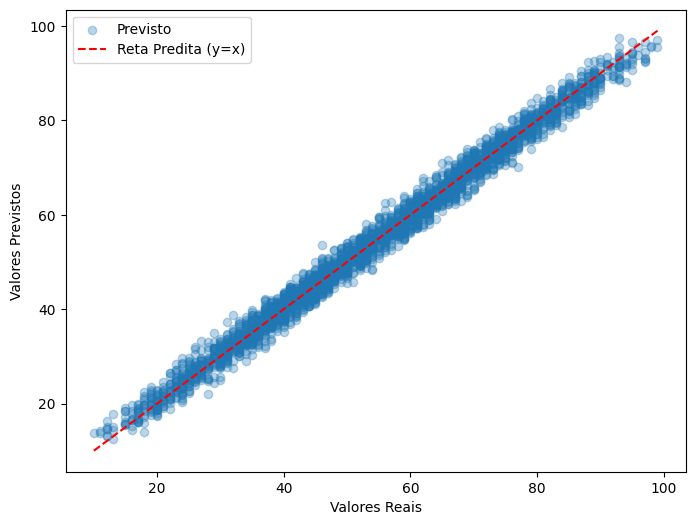

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, label='Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Reta Predita (y=x)', linestyle='--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.legend()
plt.show()

*Avaliação de Performance*
*MAE - Mean Absolute Error (Erro Médio do Modelo)* 
$$
MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
$$

*MSE - Mean Squared Error* (Erro Médio ao Quadrado do modelo)*
$$
MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

*RMSE - Root Mean Squared Error (Raiz de MSE)*
$$
RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}
$$

*$R^2$ - Coeficiente de Determinação:*
$$
R^2 = 1 - \frac{\sum (y_r - \hat{y}_i)^2}{\sum (y_r - y_b)^2}
$$

In [60]:
def avaliar_modelo(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.2f}')

In [61]:
avaliar_modelo(y_test, y_pred)

MAE: 1.61
MSE: 4.07
RMSE: 2.02
R2: 0.99


*Análise de Resíduos*

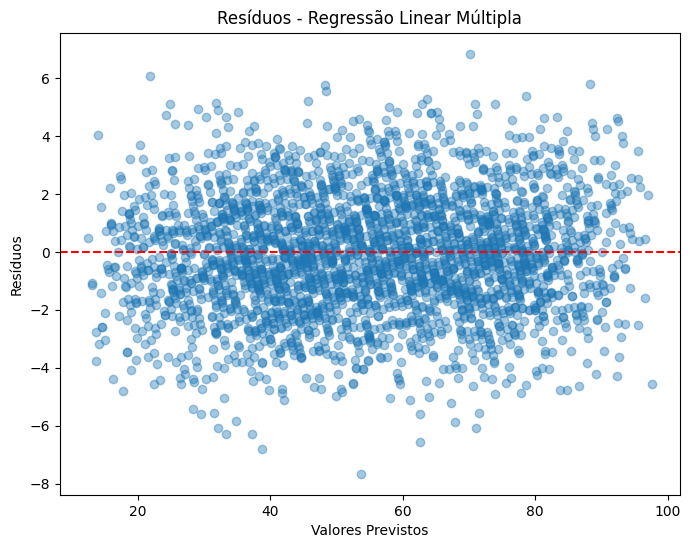

In [62]:
residuos = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos - Regressão Linear Múltipla')
plt.show()

*Otimização e Regularização*
- Minimização da Função custo:
$$
Custo = \sum (y - \hat{y})^2
$$
- Reduz Coeficientes altos, Todas variáveis são importantes 
$$
Custo Ridge = \sum (y - \hat{y})^2 + \lambda\sum\beta_i^2
$$
- Reduz e pode zerar Coeficientes, nem todas variáveis são importantes
$$
Custo Lasso = \sum (y - \hat{y})^2 + \lambda\sum|\beta_i| 
$$

In [126]:
ridge = Ridge(alpha=0.1)

ridge.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [115]:
y_ridge = ridge.predict(x_test)

avaliar_modelo(y_test,y_ridge)

MAE: 1.64
MSE: 4.25
RMSE: 2.06
R2: 0.99


In [125]:
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [124]:
y_lasso = lasso.predict(x_test)
avaliar_modelo(y_test, y_lasso)

MAE: 1.61
MSE: 4.07
RMSE: 2.02
R2: 0.99


*Cálculo dos resíduos*

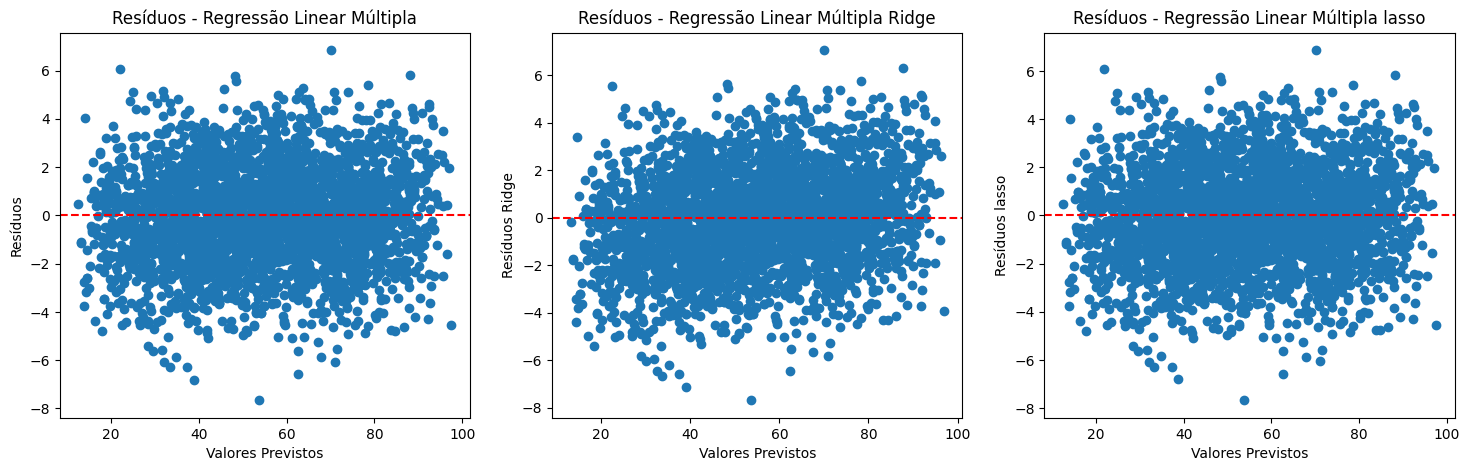

In [127]:
residuos_ridge = y_test - y_ridge
residuos_lasso = y_test - y_lasso
residuos = y_test - y_pred

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.scatter(x=y_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos - Regressão Linear Múltipla')

plt.subplot(1,3,2)
plt.scatter(x=y_ridge, y=residuos_ridge)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos Ridge')
plt.title('Resíduos - Regressão Linear Múltipla Ridge')

plt.subplot(1,3,3)
plt.scatter(x=y_lasso, y=residuos_lasso)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos lasso')
plt.title('Resíduos - Regressão Linear Múltipla lasso')
plt.show()

Pouca diferença entre o modelo base, ridge e lasso, prosseguiremos com o modelo base.

In [69]:
joblib.dump(modelo, '../models/modelo_regressao_linear.pkl')
joblib.dump(ohe, '../models/modelo_ohe.pkl')
joblib.dump(scaler, '../models/modelo_scaler.pkl')
joblib.dump(list(x.columns), '../models/modelo_colunas.pkl')

['../models/modelo_colunas.pkl']

*Classe de Previsão*

In [102]:
class ModeloRegressao:
    def __init__(self):
        self.modelo = joblib.load('../models/modelo_regressao_linear.pkl')
        self.ohe = joblib.load('../models/modelo_ohe.pkl')
        self.scaler = joblib.load('../models/modelo_scaler.pkl')
        self.colunas = joblib.load('../models/modelo_colunas.pkl')

        self.colunas_categoricas = ['extracurricular_activities']
        self.colunas_numericas = [
            'hours_studied',
            'previous_scores',
            'sleep_hours',
            'sample_question_papers_practiced'
        ]
    
    def preprocessar(self, df):
        # Aplicar o One-Hot Encoding
        ohe_array = self.ohe.transform(df[self.colunas_categoricas])
        ohe_columns = self.ohe.get_feature_names_out(self.colunas_categoricas)
        df_ohe = pd.DataFrame(ohe_array, columns=ohe_columns, index=df.index)

        df_num = df.drop(self.colunas_categoricas, axis=1)
        # Combinar as colunas numéricas e codificadas
        df_final = pd.concat([df_num, df_ohe], axis=1)
        df_final = df_final.reindex(columns=self.colunas, fill_value=0)

        # Aplicar a escala
        df_final[self.colunas_numericas] = self.scaler.transform(df_final[self.colunas_numericas])

        return df_final
    
    def predict(self, dados_aluno):
        if isinstance(dados_aluno, dict):
            df_novo = pd.DataFrame([dados_aluno])
        else:
            df_novo = dados_aluno.copy()
        df_preprocessado = self.preprocessar(df_novo)
        pred = self.modelo.predict(df_preprocessado)
        return pred.round(2)

In [82]:
novo_aluno = {
    "hours_studied": 5,
    'previous_scores': 70,
    'extracurricular_activities': "No",
    'sleep_hours': 7,
    'sample_question_papers_practiced': 5,
    'reading_score': 72
}

In [103]:
regressor = ModeloRegressao()
predicao = regressor.predict(novo_aluno)
print(f'Predição do Performance Index para o novo aluno: {predicao}')

Predição do Performance Index para o novo aluno: [55.85]
